In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")
sns.set_palette("colorblind")


available_metrics = {
    "duration": "Benchmark Duration (s)",
    # "completed": "Completed Requests",
    # "request_throughput": "Request Throughput (req/s)",
    # "input_throughput": "Input Throughput (tokens/s)",
    # "output_throughput": "Output Throughput (tokens/s)",
    "mean_ttft_ms": "Mean TTFT (ms)",
    "median_ttft_ms": "Median TTFT (ms)",
    # "std_ttft_ms": "Std Dev TTFT (ms)",
    "p99_ttft_ms": "P99 TTFT (ms)",
    "mean_tpot_ms": "Mean TPOT (ms)",
    "median_tpot_ms": "Median TPOT (ms)",
    # "std_tpot_ms": "Std Dev TPOT (ms)",
    "p99_tpot_ms": "P99 TPOT (ms)",
    # "mean_itl_ms": "Mean ITL (ms)",
    # "median_itl_ms": "Median ITL (ms)",
    # "std_itl_ms": "Std Dev ITL (ms)",
    # "p99_itl_ms": "P99 ITL (ms)",
    # "mean_e2e_latency_ms": "Mean E2E Latency (ms)",
    # "median_e2e_latency_ms": "Median E2E Latency (ms)",
}

In [11]:
# Function to create a bar chart for a specific metric
def plot_metric_by_strategy(file_name, metric):
    df = pd.read_csv(file_name)
    df = df[df['gpu_type'] != 'gpu_type']
    df[metric] = pd.to_numeric(df[metric], errors='raise')
    
    # Create a wider figure
    plt.figure(figsize=(8, 5))
    
    # Wrap long benchmark labels
    df['benchmark_label'] = df['benchmark_label'].str.replace("_", " ")
    df['wrapped_label'] = df['benchmark_label'].apply(lambda x: '\n'.join(wrap(x, 20)))
    
    # Define the order of strategies
    strategy_order = ['prefix_aware', 'pow_of_2', 'round_robin']
    
    # Create the grouped bar chart with specified order
    ax = sns.barplot(x='wrapped_label', y=metric, hue='scheduler_strategy', 
                     hue_order=strategy_order, data=df)
    
    # Add value labels on top of each bar
    for i, p in enumerate(ax.patches):
        value = p.get_height()
        text = f"{value:.1f}"
        ax.annotate(text, (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom')
    
    # Customize the plot
    plt.title(f"{available_metrics[metric]} by Routing Strategy")
    plt.xlabel('Benchmark Label')
    plt.ylabel(available_metrics[metric])
    
    # Improve legend labels
    strategy_labels = {
        'prefix_aware': 'Prefix Aware',
        'pow_of_2': 'Power of 2',
        'round_robin': 'Round Robin'
    }
    handles, labels = ax.get_legend_handles_labels()
    # Place legend to the right of the plot
    ax.legend(handles, [strategy_labels[label] for label in labels], 
              title="Routing Strategy", 
              bbox_to_anchor=(1.05, 1), 
              loc='upper left')
    
    # Adjust layout to make sure everything fits
    plt.tight_layout()
    plt.show()

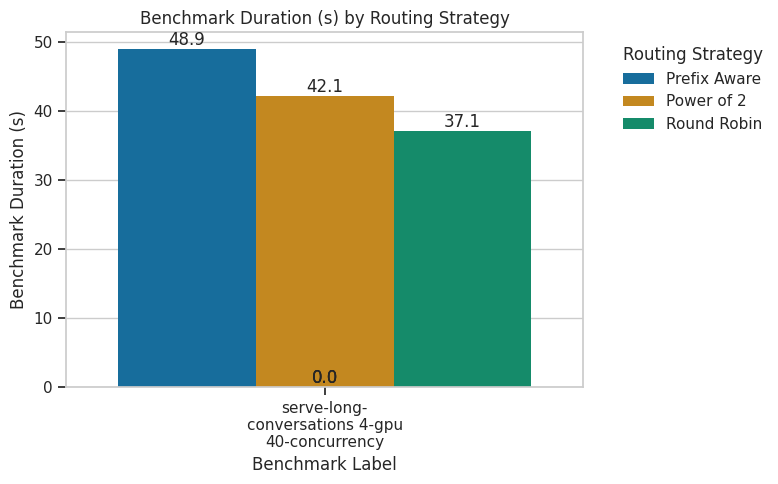

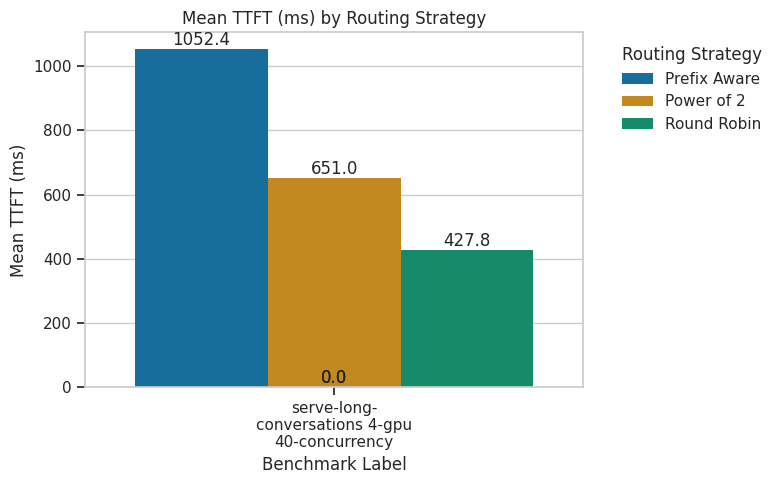

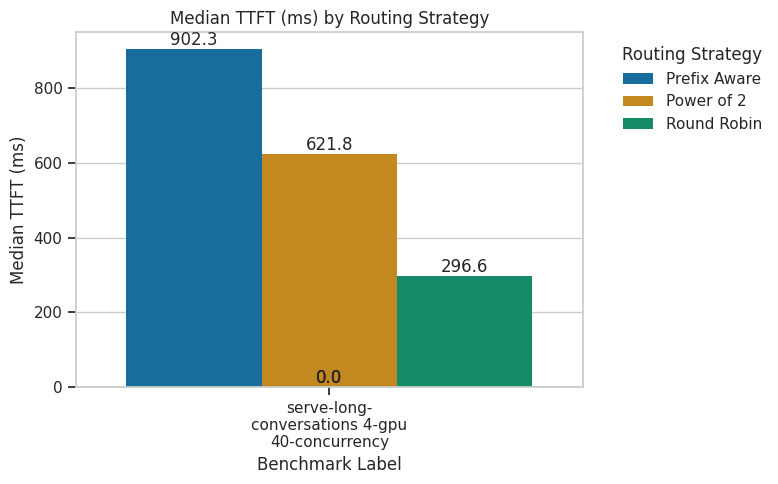

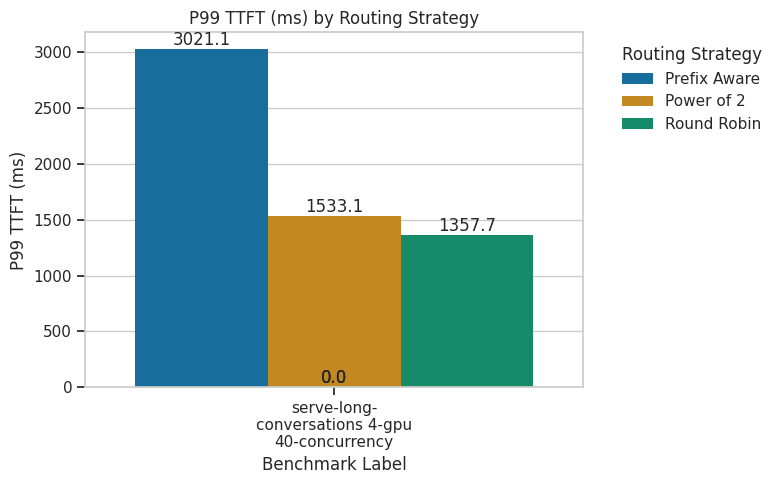

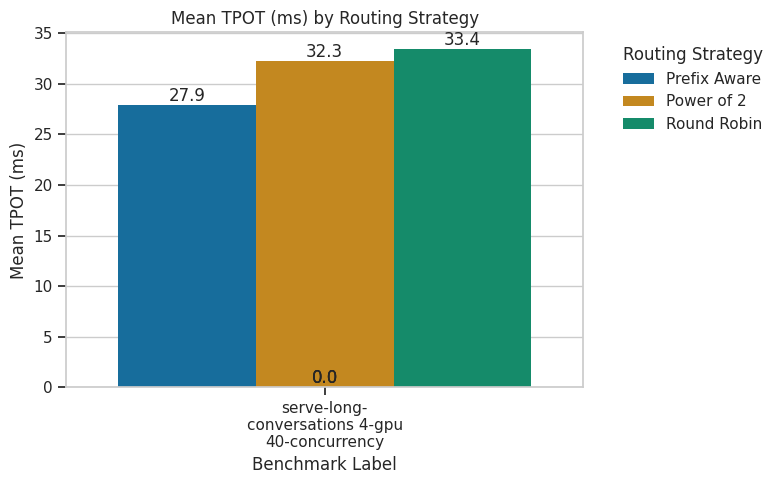

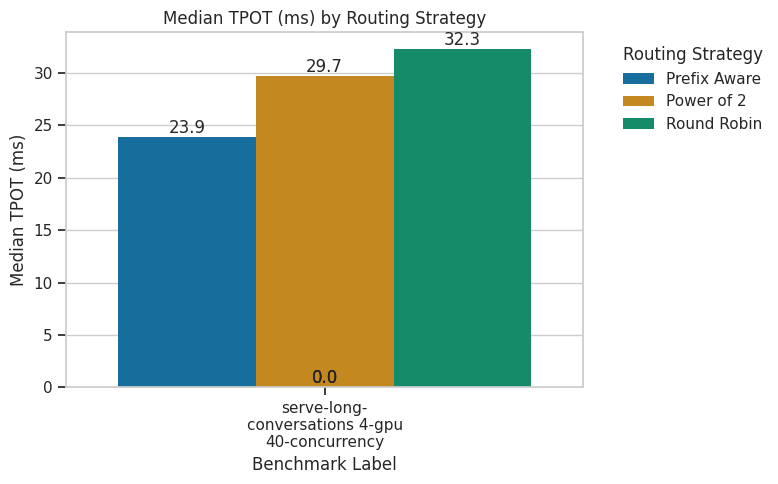

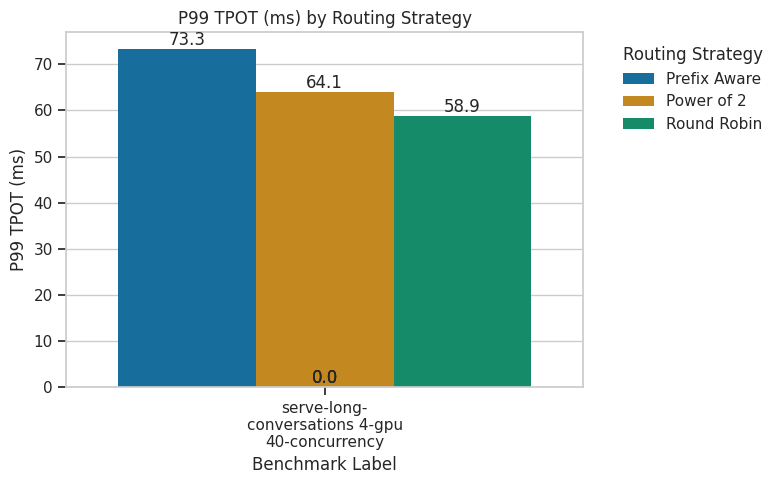

In [12]:
for metric in available_metrics:
    plot_metric_by_strategy("chosen_sweep_results.csv", metric)